<a href="https://colab.research.google.com/github/YLysov0017/PETUXON/blob/master/ML_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install tensorflow

In [21]:
from sklearn.datasets import load_iris
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization

#### Установка персонального параметра генератора сл. чисел!!!

In [4]:
from tensorflow.keras.utils import set_random_seed

set_random_seed( 8 )

# для абсолютной повторяемости желательно еще включать детерминизм, особно при работе на GPU,
#но пока можно ограничиться только set_random_seed
#tf.config.experimental.enable_op_determinism()

### Классификация

In [5]:
ds = pd.read_csv('/content/classify08.csv')

x = ds[['Свойство1', 'Свойство2', 'Свойство3', 'Свойство4']]
y = ds['Класс']

xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

nn = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 12, activation = "relu" ),
    Dense( units = 8, activation = "relu" ),
    Dense( units = 6, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] )

nn.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [6]:
hist = nn.fit( xTrain, yTrain, epochs = 40, batch_size = 8, validation_split = 0.1 )

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - categorical_accuracy: 0.3167 - loss: 1.1152 - val_categorical_accuracy: 0.4286 - val_loss: 1.0857
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - categorical_accuracy: 0.3917 - loss: 1.1038 - val_categorical_accuracy: 0.4286 - val_loss: 1.0839
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.5167 - loss: 1.0961 - val_categorical_accuracy: 0.4286 - val_loss: 1.0824
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - categorical_accuracy: 0.5333 - loss: 1.0898 - val_categorical_accuracy: 0.5714 - val_loss: 1.0805
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - categorical_accuracy: 0.5167 - loss: 1.0842 - val_categorical_accuracy: 0.5714 - val_loss: 1.0781
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.5000 - loss: 1.0787 - val_categorical_accuracy: 0.5714 - val_loss: 1.0757
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.4833 - loss: 1.07

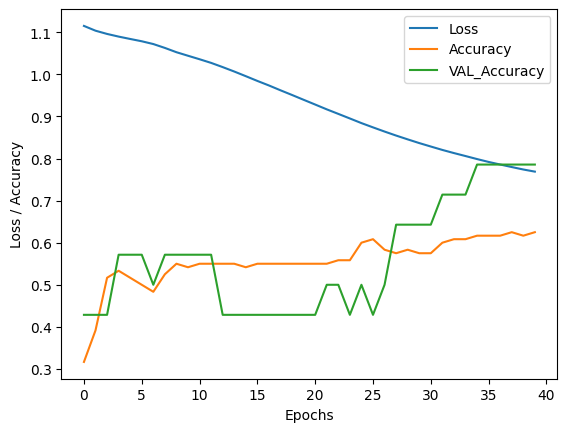

In [7]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

In [8]:
nn.evaluate(xTest, yTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.6061 - loss: 0.7921


[0.792050838470459, 0.6060606241226196]

In [9]:
# "произвольный" пример возьмем из тестового набора
from random import randint


sampleIndex = randint(0, 20)
yPred = nn.predict( xTest.to_numpy()[ sampleIndex ].reshape(1,-1) )

predLabel = np.argmax( yPred )
actLabel = np.where(yTest[sampleIndex] == 1)[0][0]
print(f"Предсказание: {predLabel}, На самом деле: {int(actLabel)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Предсказание: 1, На самом деле: 1


### Работа с переобучением модели

Искусственно создаем переобученную модель и без изменения ее структуры (количество нейронов в слоях) добиваемся снижения эффекта переобучения:
* Слои прореживания Dropout
* L1, L2, L1L2 регуляризация

In [10]:
ohe = OneHotEncoder( sparse_output = False )
yEnc = ohe.fit_transform( y.to_numpy().reshape(-1, 1) )

xNorm = ( x - np.min(x, axis = 0) ) / ( np.max(x, axis = 0) - np.min(x, axis = 0) )

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, yEnc, train_size = 0.67)

nnOver = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu" ),
    Dense( units = 128, activation = "relu" ),
    Dense( units = 64, activation = "relu" ),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Намеренно огромное кол-во нейронов

nnOver.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [11]:
hist = nnOver.fit( xTrain, yTrain, epochs = 400, batch_size = 10, validation_split = 0.1 ) # Много эпох

Epoch 1/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - categorical_accuracy: 0.5000 - loss: 1.0753 - val_categorical_accuracy: 0.7143 - val_loss: 1.0354
Epoch 2/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - categorical_accuracy: 0.6833 - loss: 1.0089 - val_categorical_accuracy: 0.7143 - val_loss: 0.9517
Epoch 3/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7167 - loss: 0.9264 - val_categorical_accuracy: 0.7143 - val_loss: 0.8546
Epoch 4/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.6917 - loss: 0.8228 - val_categorical_accuracy: 0.7143 - val_loss: 0.7612
Epoch 5/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.7250 - loss: 0.7256 - val_categorical_accuracy: 0.7143 - val_loss: 0.7049
Epoch 6/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7417 - loss: 0.6489 - val_categorical_accuracy: 0.7143 - val_loss: 0.6846
Epoch 7/400
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - categorical_accuracy: 0.7583 - los

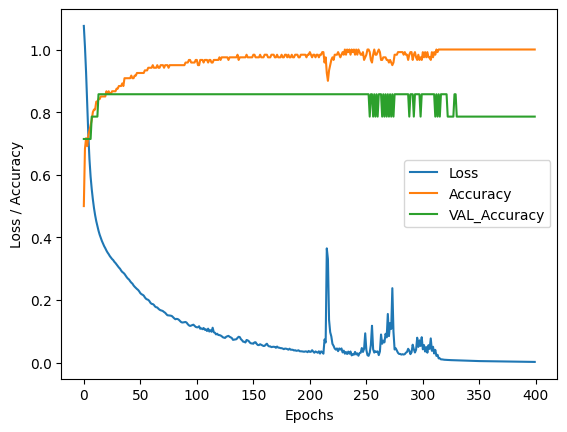

In [12]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

#### Чиним безобразие

In [13]:
from tensorflow.keras.layers import Dropout
nnOverHealed = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = 128, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = 64, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.01) ),
    Dropout(0.5),
    Dense( units = yEnc.shape[1], activation = "softmax" )
] ) # Отключаем случайную половину нейронов и добавляем регуляризацию L2

nnOverHealed.compile( loss = "categorical_crossentropy",
            optimizer = "adam", metrics = ["categorical_accuracy"] )

In [14]:
hist = nnOverHealed.fit( xTrain, yTrain, epochs = 50, batch_size = 10, validation_split = 0.1 ) # Уменьшаем эпохи

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - categorical_accuracy: 0.3167 - loss: 3.5115 - val_categorical_accuracy: 0.7143 - val_loss: 3.2654
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4167 - loss: 3.0762 - val_categorical_accuracy: 0.6429 - val_loss: 2.8756
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4083 - loss: 2.7361 - val_categorical_accuracy: 0.7143 - val_loss: 2.5594
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4000 - loss: 2.4623 - val_categorical_accuracy: 0.7857 - val_loss: 2.3021
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4083 - loss: 2.2326 - val_categorical_accuracy: 0.7143 - val_loss: 2.0809
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.4000 - loss: 2.0569 - val_categorical_accuracy: 0.7857 - val_loss: 1.8964
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.5333 - loss: 1.8663 - v

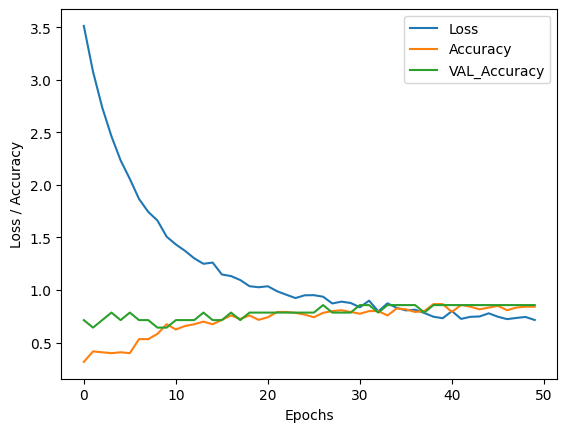

In [15]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["categorical_accuracy"], label = "Accuracy" )

plt.plot( hist.history["val_categorical_accuracy"], label = "VAL_Accuracy" )
plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

### Регрессия

In [35]:
from sklearn.preprocessing import RobustScaler

ds = pd.read_csv('/content/regress08.csv')

x = ds[['V1', 'V2', 'V3', 'V4']]
y = ds['Target']

scaler = RobustScaler()
xNorm = scaler.fit_transform(x)

xTrain, xTest, yTrain, yTest = train_test_split( xNorm, y, train_size = 0.67, random_state=8)

nn = Sequential( [
    Input( shape = ( xNorm.shape[1],) ),
    Dense( units = 256, activation = "relu" ),
    BatchNormalization(),
    Dense( units = 128, activation = "relu" ),
    BatchNormalization(),
    Dense( units = 64, activation = "relu" ),
    BatchNormalization(),
    Dense( units = 32, activation = "relu" ),
    Dense( units = 1 )
] )

nn.compile( loss = "mse",
            optimizer = "adam", metrics = ["mae", "mse"] )

In [41]:
hist = nn.fit( xTrain, yTrain, epochs = 200, batch_size = 64, validation_split = 0.1 )

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 991.4565 - mae: 22.5069 - mse: 991.4565 - val_loss: 5662.6079 - val_mae: 53.8690 - val_mse: 5662.6079
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 724.7415 - mae: 20.1167 - mse: 724.7415 - val_loss: 5620.5503 - val_mae: 53.5162 - val_mse: 5620.5503
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 648.9150 - mae: 20.1207 - mse: 648.9150 - val_loss: 3845.7102 - val_mae: 46.5843 - val_mse: 3845.7102
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 599.3220 - mae: 19.5903 - mse: 599.3220 - val_loss: 4127.0298 - val_mae: 47.5881 - val_mse: 4127.0298
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 483.3360 - mae: 17.5468 - mse: 483.3360 - val_loss: 5277.3755 - val_mae: 53.2266 - val_mse: 5277.3755
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 457.1526 - mae: 17.5961 - mse: 457.1526 - val_loss: 4625.9907 - val_mae: 50.2978 - val_mse: 4625.9907
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 

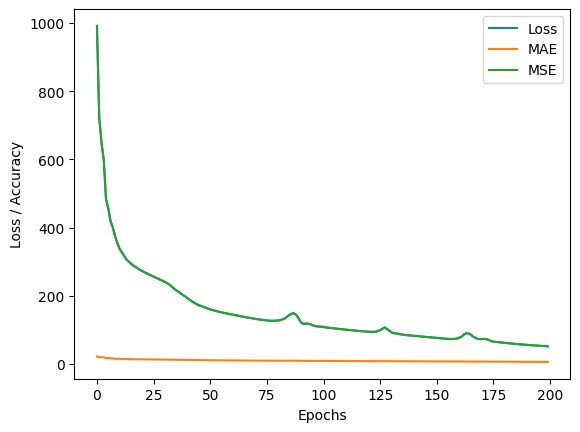

In [46]:
plt.plot( hist.history["loss"], label = "Loss" )
plt.plot( hist.history["mae"], label = "MAE" )
plt.plot( hist.history["mse"], label = "MSE" )

plt.xlabel("Epochs")
plt.ylabel("Loss / Accuracy")
plt.legend()
plt.show()

In [43]:
nn.evaluate(xTest, yTest)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3659.4382 - mae: 44.0970 - mse: 3659.4382


[3659.438232421875, 44.09698486328125, 3659.438232421875]

In [50]:
yPred = nn.predict( xTest )

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(yTest, yPred)
mse = mean_squared_error(yTest, yPred)
rmse = np.sqrt(mse)
r2 = r2_score(yTest, yPred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

MAE: 44.097
RMSE: 60.493
R²: 0.474
